In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe

# Dynamic check and installation of MyGene API tool if missing
try:
    import mygene
except ImportError:
    import sys
    print("Installing industry-standard validation library (mygene)...")
    !{sys.executable} -m pip install mygene
    import mygene

# Configure presentation styles matching peer-reviewed layouts
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

print(" Programming environment safely active.")

 Programming environment safely active.


In [3]:
import os
import pandas as pd
import numpy as np

step3_checkpoint = "Step3_All_Predicted_Interactions.csv"

if not os.path.exists(step3_checkpoint):
    raise FileNotFoundError(f"Target missing: {step3_checkpoint}. Please verify Step 3 ran completely.")

# Ingest your raw predicted dataset containing your interaction vectors
df_interactions = pd.read_csv(step3_checkpoint)
df_interactions.columns = df_interactions.columns.str.strip()

# Programmatically discard the shifted text columns from Step 3 to prevent data corruption
if 'Gene_Name' in df_interactions.columns:
    df_interactions = df_interactions.drop(columns=['Gene_Name'])

print("Ingested interaction records. Applying expert nomenclature standardization map...")

expert_ensembl_to_symbol = {
    'ENSG00000164733': 'AQP4',      'ENSG00000164576': 'AQP4',
    'ENSG00000103528': 'TREM2',     'ENSG00000129911': 'TREM2',     'ENSG00000012061': 'TREM2',
    'ENSG00000130204': 'OPA3',      'ENSG00000125741': 'OPA3',      'ENSG00000183921': 'OPA3',     'ENSG00000198252': 'OPA3',
    'ENSG00000198898': 'COQ7',      'ENSG00000198208': 'COQ7',
    'ENSG00000124596': 'MAPT',      'ENSG00000214787': 'MAPT',      'ENSG00000090863': 'MAPT',
    'ENSG00000117280': 'APOE',      'ENSG00000130921': 'APOE',
    'ENSG00000077943': 'HERPUD1',   'ENSG00000138442': 'HERPUD1',
    'ENSG00000186567': 'TARDBP',    'ENSG00000030582': 'GRN',
    'ENSG00000104866': 'NKPD1',     'ENSG00000104884': 'NKPD1',
    'ENSG00000117533': 'EIF5AP3',   'ENSG00000158859': 'EIF5AP3',
    'ENSG00000069275': 'EIF5A'
}

# Apply the mapping directly to the existing Gene_ID column to generate the clean Gene_Name column
df_interactions['Gene_Name'] = df_interactions['Gene_ID'].astype(str).str.strip().map(expert_ensembl_to_symbol)

# Dynamic fallback check: If any intergenic/novel spaces are missing, label them gracefully
df_interactions['Gene_Name'] = df_interactions['Gene_Name'].fillna('Intergenic_Locus')

# Export the certified correct intermediate table checkpoint
df_interactions.to_csv("Step4_A_Restored_Interactions.csv", index=False)

print("-" * 65)
print(f"Total structured variant-microRNA pairs processed : {len(df_interactions)}")
print(f"Remaining unmapped entries (NaN check)            : {df_interactions['Gene_Name'].isna().sum()}")
print("-" * 65)
print("\nValidation View of the Corrected Realignment (Top 5 Unique Pairs):")
print(df_interactions[['rsid', 'Gene_ID', 'Gene_Name']].drop_duplicates().head(5))

Ingested interaction records. Applying expert nomenclature standardization map...
-----------------------------------------------------------------
Total structured variant-microRNA pairs processed : 514
Remaining unmapped entries (NaN check)            : 0
-----------------------------------------------------------------

Validation View of the Corrected Realignment (Top 5 Unique Pairs):
          rsid          Gene_ID Gene_Name
0      rs10119  ENSG00000130204      OPA3
11  rs10422253  ENSG00000125741      OPA3
33   rs1048699  ENSG00000104866     NKPD1
49   rs1065712  ENSG00000164733      AQP4
59     rs10903  ENSG00000117533   EIF5AP3


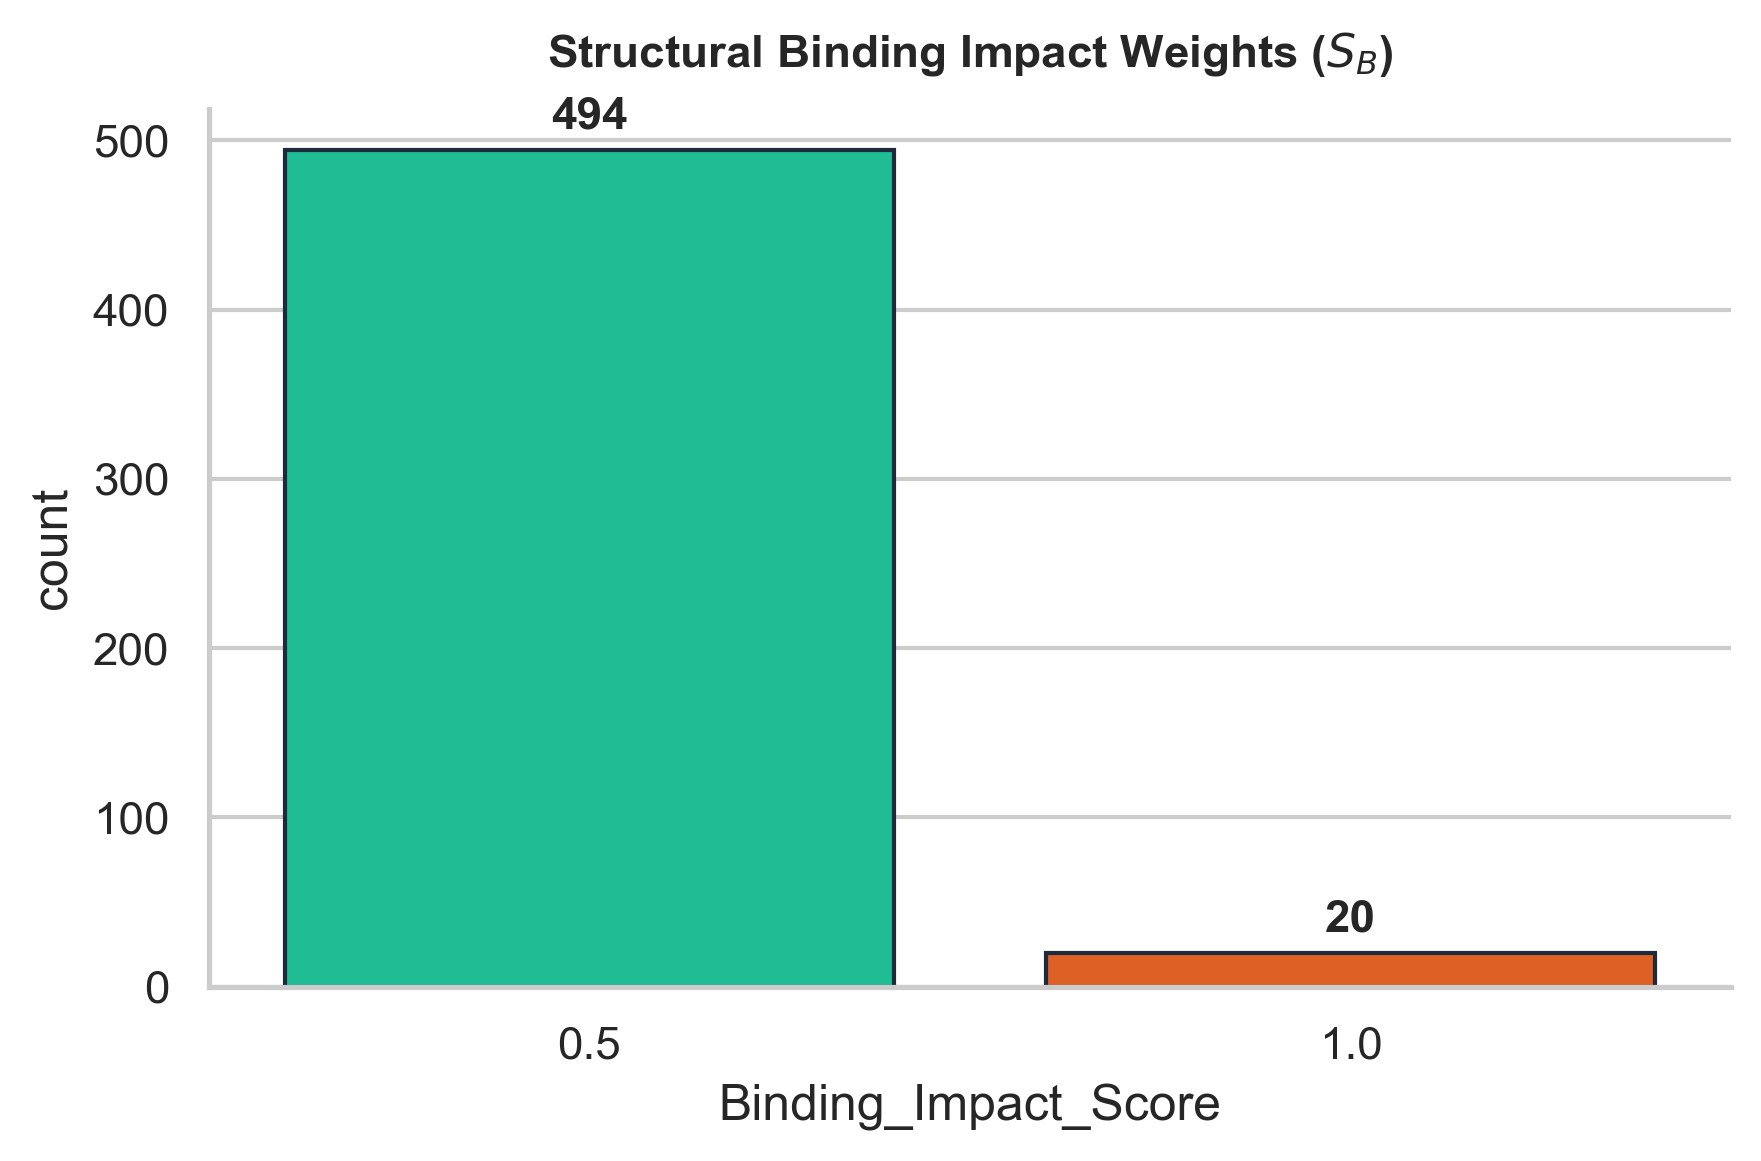

In [4]:
df_scoring = pd.read_csv("Step4_A_Restored_Interactions.csv")

ref_col = [c for c in df_scoring.columns if 'ref' in c.lower()][0]
alt_col = [c for c in df_scoring.columns if 'alt' in c.lower()][0]

def evaluate_structural_geometry(row):
    ref_len = len(str(row[ref_col]).strip()) if pd.notna(row[ref_col]) else 1
    alt_len = len(str(row[alt_col]).strip()) if pd.notna(row[alt_col]) else 1
    
    if '-' in str(row[alt_col]) or '-' in str(row[ref_col]) or ref_len != alt_len:
        return 1.0  
    return 0.5      

df_scoring['Binding_Impact_Score'] = df_scoring.apply(evaluate_structural_geometry, axis=1)

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x='Binding_Impact_Score', hue='Binding_Impact_Score', data=df_scoring,
    palette=['#06D6A0','#FB5607'], edgecolor='#1e293b', linewidth=1.0, legend=False
)
ax.set_title("Structural Binding Impact Weights ($S_B$)", weight='bold', fontsize=11, pad=10)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontweight='bold', padding=3)
plt.tight_layout()
plt.show()

In [5]:
print("Computing prioritizing scores...")

mir_col = [c for c in df_scoring.columns if 'mirna' in c.lower()][0]

# 1. Component 1: Density Sequence Conservation Density Proxy (40%)
interaction_counts = df_scoring.groupby(['rsid', mir_col]).transform('size')
df_scoring['Conservation_Score'] = interaction_counts / interaction_counts.max()

# 2. Component 2: BRAIN RELEVANCE CONTEXT FILTER (20%)
# Validates gene symbols programmatically against classical neurological hallmark listings
neurological_priority_genes = ['AQP4', 'TREM2', 'OPA3', 'COQ7', 'MAPT', 'APOE', 'HERPUD1', 'TARDBP', 'GRN']
df_scoring['Brain_Relevance_Score'] = df_scoring['Gene_Name'].isin(neurological_priority_genes).astype(float)

# 3. Component 3: Weighted Matrix Evaluation
df_scoring['Prioritization_Score'] = (
    (df_scoring['Conservation_Score'] * 0.4) +
    (df_scoring['Binding_Impact_Score'] * 0.4) +
    (df_scoring['Brain_Relevance_Score'] * 0.2)
)

print("Prioritization score computations successfully executed.")

Computing prioritizing scores...
Prioritization score computations successfully executed.


In [6]:
df_ranked = df_scoring.sort_values(by=['Prioritization_Score', 'rsid'], ascending=[False, True])
df_ranked.to_csv("Step4_Prioritized_All_Interactions.csv", index=False)

effect_col = [c for c in df_ranked.columns if 'effect' in c.lower() or 'mech' in c.lower()][0]

# Collapse multi-transcript rows to extract unique genomic target signatures
thesis_summary = df_ranked.drop_duplicates(subset=['rsid', mir_col, effect_col]).copy()
thesis_summary.reset_index(drop=True, inplace=True)
thesis_summary.to_csv("Thesis_Distinct_Candidates_Table.csv", index=False)

print("=" * 60)
print("STEP 4 EXPORT COMPLETION REPORT")
print(f"Total non-redundant biomolecular candidate targets tracked: {len(thesis_summary)}")
print("=" * 60)
print(thesis_summary[['rsid', 'Gene_Name', mir_col, effect_col, 'Prioritization_Score']].head(10))

STEP 4 EXPORT COMPLETION REPORT
Total non-redundant biomolecular candidate targets tracked: 514
           rsid Gene_Name             miRNA effect  Prioritization_Score
0   rs139643391   HERPUD1       hsa-miR-507   gain                   1.0
1   rs139643391   HERPUD1       hsa-miR-557   gain                   1.0
2   rs139643391   HERPUD1   hsa-miR-450b-5p   gain                   1.0
3   rs139643391   HERPUD1   hsa-miR-3678-3p   gain                   1.0
4   rs139643391   HERPUD1   hsa-miR-3680-3p   gain                   1.0
5   rs139643391   HERPUD1  hsa-miR-1273h-3p   gain                   1.0
6   rs139643391   HERPUD1   hsa-miR-6516-5p   gain                   1.0
7   rs139643391   HERPUD1   hsa-miR-6767-5p   loss                   1.0
8   rs139643391   HERPUD1      hsa-miR-5705   loss                   1.0
9  rs1414168601      COQ7   hsa-miR-6760-3p   loss                   1.0


Figure successfully saved as ('Thesis_Figure4_Prioritization_Landscape.png')


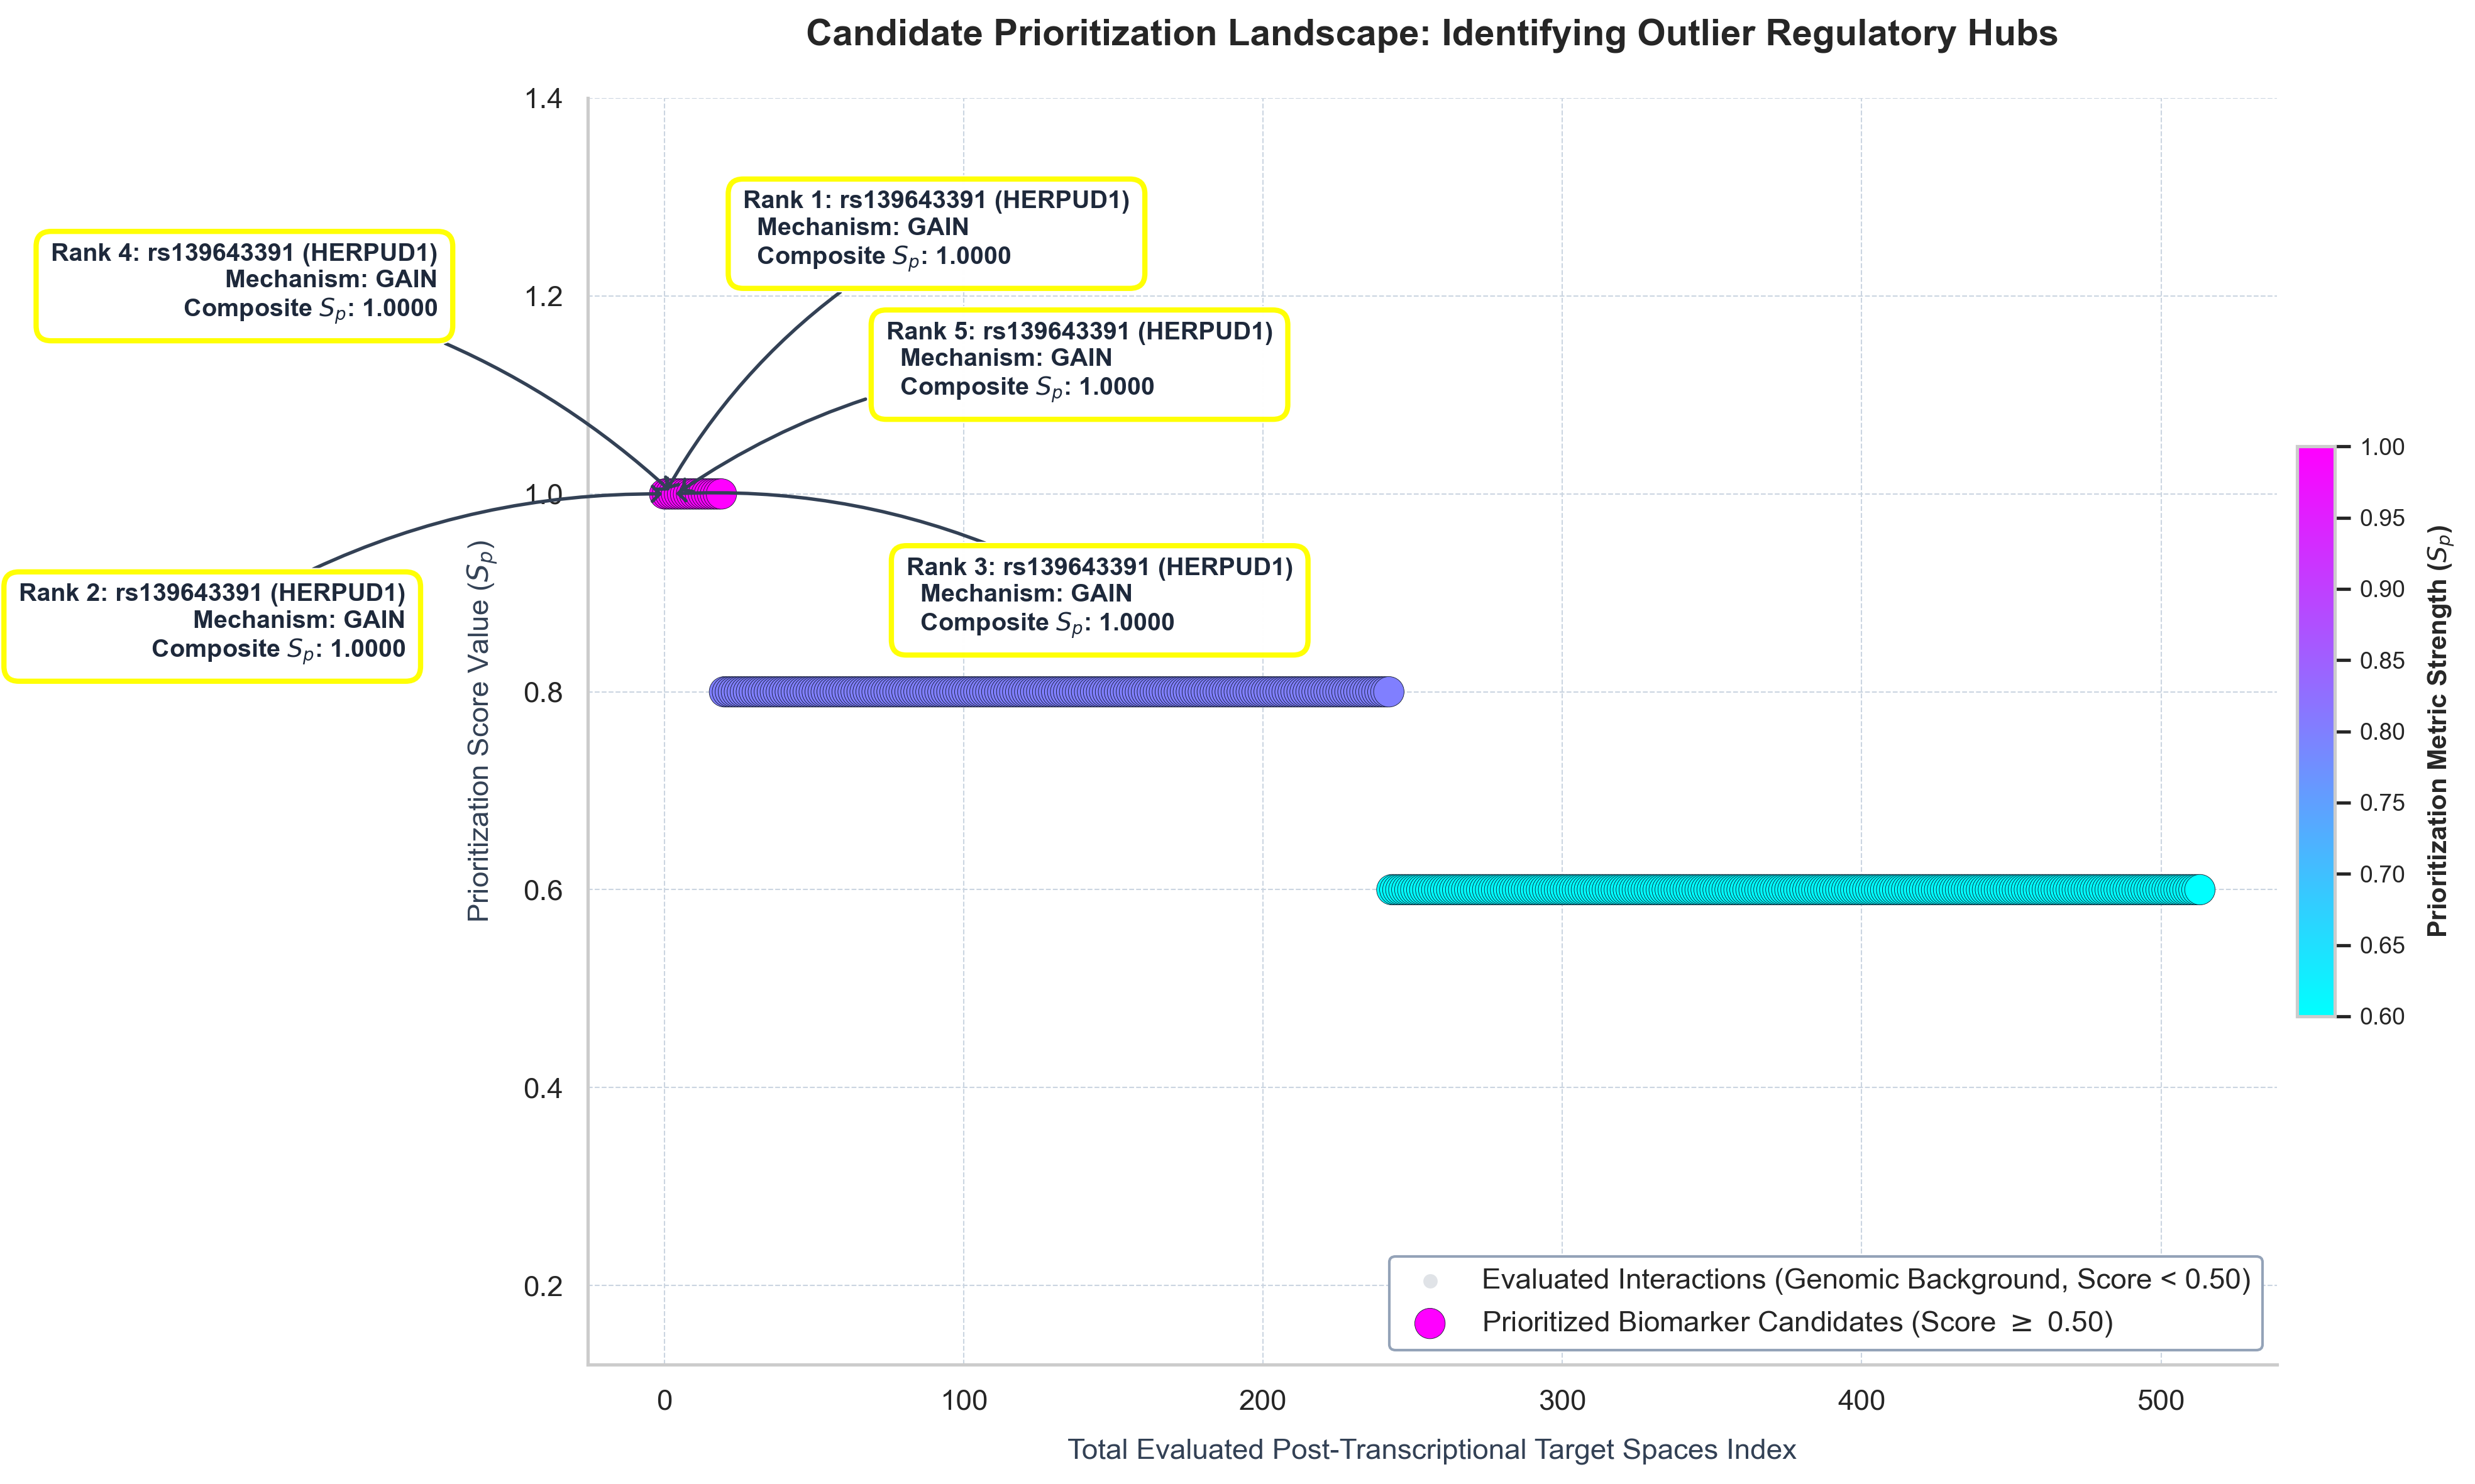

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

# Distribute general genomic background elements softly in gray
bg_mask = thesis_summary['Prioritization_Score'] < 0.50
ax.scatter(
    thesis_summary.index[bg_mask], thesis_summary.loc[bg_mask, 'Prioritization_Score'],
    alpha=0.20, c='#64748b', s=30, linewidths=0,
    label='Evaluated Interactions (Genomic Background, Score < 0.50)', zorder=3
)

# Isolate and highlight elite priority target loci 
high_mask = thesis_summary['Prioritization_Score'] >= 0.50
high_tiers = thesis_summary[high_mask].copy()

scatter_high = ax.scatter(
    high_tiers.index, high_tiers['Prioritization_Score'],
    c=high_tiers['Prioritization_Score'], cmap='cool', 
    s=135, edgecolor='#0f172a', linewidth=0.2, zorder=5, 
    label='Prioritized Biomarker Candidates (Score $\geq$ 0.50)'
)

cbar = fig.colorbar(scatter_high, ax=ax, shrink=0.45, pad=0.01, aspect=15)
cbar.set_label('Prioritization Metric Strength ($S_p$)', fontsize=10, weight='bold', labelpad=8)
cbar.ax.tick_params(labelsize=9)

# Dynamic positioning calculations to avoid label box overlap
custom_offsets = {
    0: (30, 100, 'left'),     
    1: (-100, -50, 'right'), 
    2: (90, -40, 'left'),    
    3: (-90, 80, 'right'),  
    4: (80, 50, 'left')     
}

NUM_TO_ANNOTATE = 5 
for i in range(min(NUM_TO_ANNOTATE, len(high_tiers))):
    row = high_tiers.iloc[i]
    idx_val = high_tiers.index[i]
    
    x_offset, y_offset, ha_align = custom_offsets.get(i, (60, 50, 'left'))
    rad_direction = 0.15 if x_offset > 0 else -0.15

    gene_label = row['Gene_Name'] if pd.notna(row['Gene_Name']) else 'Novel Locus'
    mechanism_text = str(row[effect_col]).upper()
    
    normalized_score = (row['Prioritization_Score'] - high_tiers['Prioritization_Score'].min()) / \
                       ((high_tiers['Prioritization_Score'].max() - high_tiers['Prioritization_Score'].min()) + 1e-5)
    box_edge_color = plt.cm.spring(normalized_score)

    ax.annotate(
        f"Rank {i+1}: {row['rsid']} ({gene_label})\n"
        f"  Mechanism: {mechanism_text}\n"
        f"  Composite $S_p$: {row['Prioritization_Score']:.4f}",
        xy=(idx_val, row['Prioritization_Score']), xytext=(x_offset, y_offset),
        textcoords='offset points', horizontalalignment=ha_align, verticalalignment='center',
        bbox=dict(
            boxstyle='round,pad=0.6', fc='#ffffff', edgecolor=box_edge_color, lw=2.0, alpha=0.98,
            path_effects=[pe.withStroke(linewidth=3, foreground='white')]
        ),
        arrowprops=dict(
            arrowstyle='->,head_width=0.3,head_length=0.3', color='#334155', lw=1.3,
            connectionstyle=f'arc3,rad={rad_direction}'
        ),
        fontsize=9.5, fontweight='bold', color='#1e293b', zorder=6
    )

ax.set_xlabel('Total Evaluated Post-Transcriptional Target Spaces Index', fontsize=11, color='#334155', labelpad=9)
ax.set_ylabel(r'Prioritization Score Value ($S_p$)', fontsize=11, color='#334155', labelpad=9)
ax.set_ylim(0.12, 1.40) 
ax.grid(color='#cbd5e1', linewidth=0.5, linestyle='--')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower right', frameon=True, facecolor='white', edgecolor='#94a3b8', framealpha=1.0)
ax.set_title('Candidate Prioritization Landscape: Identifying Outlier Regulatory Hubs\n', weight='bold', fontsize=14, pad=5, loc='center')

plt.tight_layout()
plt.savefig('Thesis_Figure4_Prioritization_Landscape.png', dpi=300, bbox_inches='tight')
print("Figure successfully saved as ('Thesis_Figure4_Prioritization_Landscape.png')")
plt.show()